<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/Taller_3_OCTUBRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TALLER EN CLASES

#HAMERSON JOEL PIARPUEZAN PIARPUEZAN

In [1]:
import pandas as pd

# Replace 'your_database.csv' with the actual path to your database file
try:
    df = pd.read_csv('weather_features.csv')
    print("Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: The file 'weather_features.csv' was not found. Please provide the correct path to your database file.")
except Exception as e:
    print(f"An error occurred: {e}")

Database loaded successfully!


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n


#Codigo para extraer los datos de interes, HUMEDAD

In [2]:
# Extract the 'humidity' column
humidity_data = df['humidity']

# Display the humidity data
display(humidity_data)

,humidity
0,77.0
1,77.0
2,78.0
3,78.0
4,78.0
...,...
122237,57.0
122238,57.0
122239,57.0
122240,65.0


#Este codigo para saber cada cuanto tiempo se tomaron las muestras de HUMEDAD, en este caso cada hora por lo cual su Fs = 1/3600

In [3]:
# Ver las primeras filas con timestamp (si existe columna de fecha/hora)
display(df.head(10))

# O si tienes columna de tiempo:
# display(df[['timestamp', 'humidity']].head(10))

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
5,2015-01-01 05:00:00+01:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
6,2015-01-01 06:00:00+01:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
7,2015-01-01 07:00:00+01:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
8,2015-01-01 08:00:00+01:00,Valencia,274.601,274.601,274.601,1005.0,71.0,1.0,307.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01d
9,2015-01-01 09:00:00+01:00,Valencia,274.601,274.601,274.601,1005.0,71.0,1.0,307.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01d


Análisis Espectral Automático

- Identifica automáticamente la banda útil de frecuencias
- Encuentra dónde está la información significativa
- Sugiere la frecuencia de corte óptima

2. Filtrado de Señal

- Aplica filtro Butterworth pasa-bajas
- Elimina ruido de alta frecuencia
- Preserva la información útil

3. Comparación Completa 📊
- Antes y después del filtrado:

- PSD con 3 métodos (Periodogram, Welch, Multitaper)
- Autocorrelación (para ver correlación temporal)
- Distribución en tiempo (histogramas)
- Distribución en frecuencia (espectrogramas)

PASO 1: PREPARANDO DATOS
⚠️  Limpieza de datos:
   - Datos originales: 122242
   - Valores no numéricos eliminados: 1
   - Datos válidos: 122241
✓ Total de muestras: 122241
✓ Frecuencia de muestreo: 0.0002777777777777778 Hz (datos horarios)
✓ Duración total: 5093.38 días

PASO 2: ANÁLISIS ESPECTRAL - IDENTIFICANDO BANDA ÚTIL
📊 Análisis del espectro:
   - Frecuencia máxima analizada: 1.39e-04 Hz
   - Potencia máxima: 9.9969e+07
   - Umbral (5% de máx): 4.9985e+06
   - Frecuencias significativas encontradas: 18
   - Frecuencia de corte sugerida: 1.56e-05 Hz
   - Período de corte: 17.78 horas (0.74 días)

PASO 3: APLICANDO FILTRO PASA-BAJAS
✓ Filtro aplicado:
   - Tipo: Butterworth pasa-bajas
   - Orden: 4
   - Frecuencia de corte: 1.56e-05 Hz
   - Frecuencia de corte normalizada: 0.1125

PASO 4: CALCULANDO MÉTRICAS

--- SEÑAL ORIGINAL ---
✓ Métricas calculadas para: Señal Original
   - PSD Periodogram: 61121 frecuencias
   - PSD Welch: 257 frecuencias
   - PSD Multitaper: 61121 frecuenci

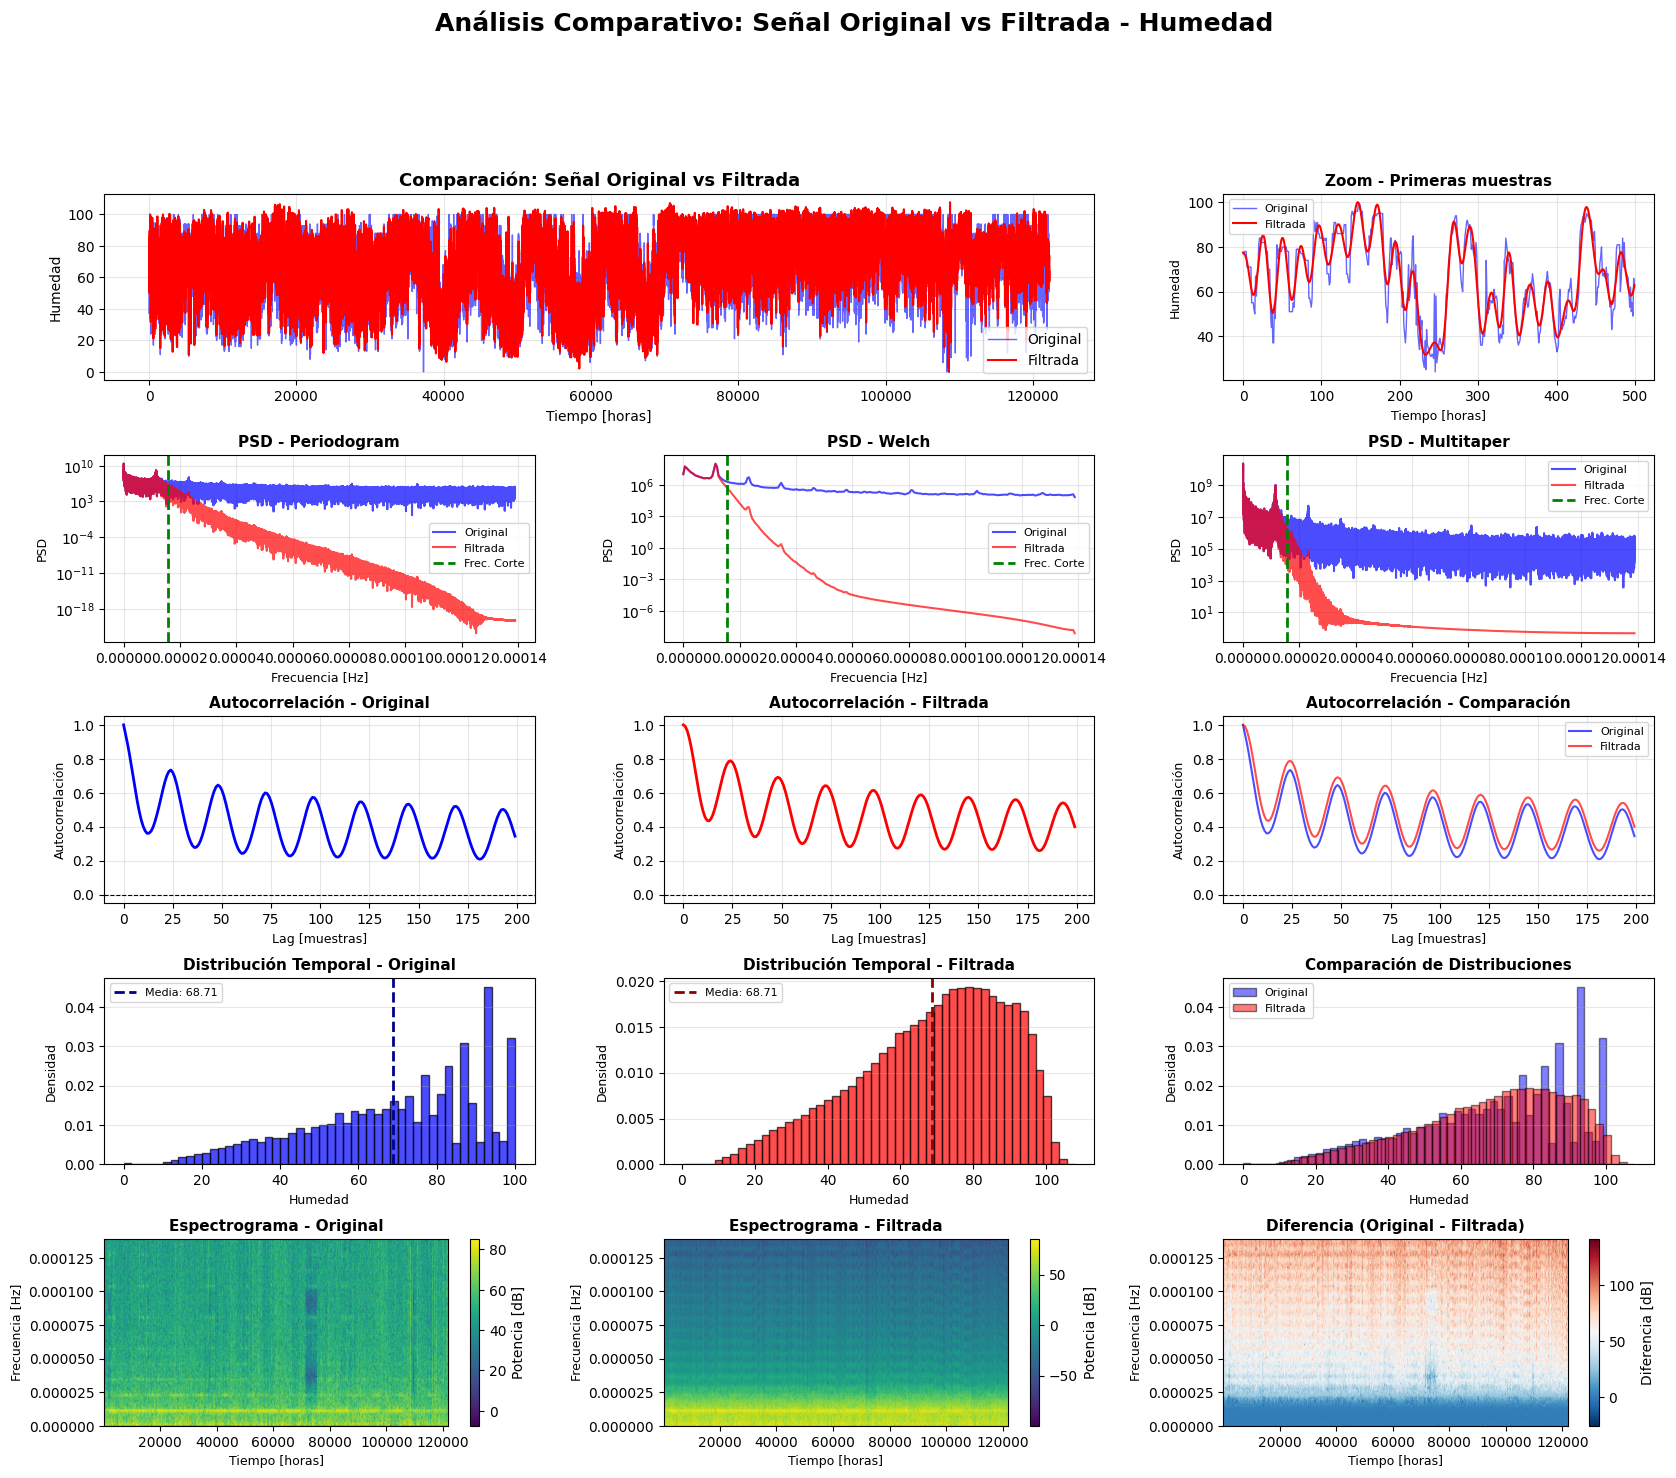

✓ Visualización completa generada

PASO 6: RESUMEN ESTADÍSTICO
               Métrica   Original   Filtrada  Cambio %
                 Media  68.713230  68.713262      0.00
        Desv. Estándar  21.850547  20.439646     -6.46
              Varianza 477.446407 417.779127    -12.50
                Mínimo   0.000000   0.426792       inf
                Máximo 100.000000 107.807828      7.81
                 Rango 100.000000 107.381037      7.38
Potencia Total (Welch) 281.588004 221.948438    -21.18

ANÁLISIS DE RESULTADOS

📊 Reducción de ruido:
   - Desv. estándar original: 21.8505
   - Desv. estándar filtrada: 20.4396
   - Reducción: 6.46%

📈 Preservación de información:
   - Media original: 68.7132
   - Media filtrada: 68.7133
   - Diferencia: 0.0000

PASO 7: GUARDANDO RESULTADOS
✓ Señales guardadas en 'humidity_signals.csv'
✓ Estadísticas guardadas en 'filtering_statistics.csv'
✓ PSD comparativa guardada en 'psd_comparison.csv'

¡ANÁLISIS COMPLETADO EXITOSAMENTE! 🎉

📁 Archivos genera

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch, periodogram, butter, filtfilt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PASO 1: CARGAR Y PREPARAR DATOS
# ============================================================================
print("="*70)
print("PASO 1: PREPARANDO DATOS")
print("="*70)

# Ya tienes tus datos cargados
# humidity_data = df['humidity']

# Limpiar datos: convertir a numérico y eliminar valores inválidos
humidity_clean = pd.to_numeric(humidity_data, errors='coerce')
humidity_original = humidity_clean.dropna().values

print(f"⚠️  Limpieza de datos:")
print(f"   - Datos originales: {len(humidity_data)}")
print(f"   - Valores no numéricos eliminados: {humidity_data.isna().sum() + (pd.to_numeric(humidity_data, errors='coerce').isna().sum() - humidity_data.isna().sum())}")
print(f"   - Datos válidos: {len(humidity_original)}")

# Frecuencia de muestreo (datos horarios)
fs = 1/3600  # Hz (1 muestra por hora)

print(f"✓ Total de muestras: {len(humidity_original)}")
print(f"✓ Frecuencia de muestreo: {fs} Hz (datos horarios)")
print(f"✓ Duración total: {len(humidity_original)/24:.2f} días\n")

# ============================================================================
# PASO 2: ANÁLISIS ESPECTRAL INICIAL (IDENTIFICAR BANDA ÚTIL)
# ============================================================================
print("="*70)
print("PASO 2: ANÁLISIS ESPECTRAL - IDENTIFICANDO BANDA ÚTIL")
print("="*70)

# Calcular PSD con Welch para análisis inicial
freq_analysis, psd_analysis = welch(humidity_original, fs=fs, nperseg=min(512, len(humidity_original)//4))

# Encontrar frecuencias significativas (por encima del umbral)
# Usamos el 5% de la potencia máxima como umbral
threshold = 0.05 * np.max(psd_analysis)
significant_freqs = freq_analysis[psd_analysis > threshold]

if len(significant_freqs) > 0:
    freq_cutoff = significant_freqs[-1]  # Última frecuencia significativa
else:
    freq_cutoff = freq_analysis[len(freq_analysis)//2]  # Usar mitad si no hay clara

# Ajustar frecuencia de corte (agregar margen del 20%)
freq_cutoff = freq_cutoff * 1.2

print(f"📊 Análisis del espectro:")
print(f"   - Frecuencia máxima analizada: {freq_analysis[-1]:.2e} Hz")
print(f"   - Potencia máxima: {np.max(psd_analysis):.4e}")
print(f"   - Umbral (5% de máx): {threshold:.4e}")
print(f"   - Frecuencias significativas encontradas: {len(significant_freqs)}")
print(f"   - Frecuencia de corte sugerida: {freq_cutoff:.2e} Hz")

# Convertir frecuencia de corte a período para interpretación
period_cutoff = 1/freq_cutoff if freq_cutoff > 0 else 0
print(f"   - Período de corte: {period_cutoff/3600:.2f} horas ({period_cutoff/86400:.2f} días)\n")

# ============================================================================
# PASO 3: DISEÑAR Y APLICAR FILTRO
# ============================================================================
print("="*70)
print("PASO 3: APLICANDO FILTRO PASA-BAJAS")
print("="*70)

# Diseñar filtro Butterworth pasa-bajas
order = 4  # Orden del filtro
nyquist = fs / 2
normal_cutoff = freq_cutoff / nyquist

# Verificar que la frecuencia de corte sea válida
if normal_cutoff >= 1:
    normal_cutoff = 0.9
    print(f"⚠️  Ajustando frecuencia de corte normalizada a {normal_cutoff}")

b, a = butter(order, normal_cutoff, btype='low', analog=False)

# Aplicar filtro
humidity_filtered = filtfilt(b, a, humidity_original)

print(f"✓ Filtro aplicado:")
print(f"   - Tipo: Butterworth pasa-bajas")
print(f"   - Orden: {order}")
print(f"   - Frecuencia de corte: {freq_cutoff:.2e} Hz")
print(f"   - Frecuencia de corte normalizada: {normal_cutoff:.4f}\n")

# ============================================================================
# FUNCIÓN AUXILIAR: CALCULAR TODAS LAS MÉTRICAS
# ============================================================================
def calculate_metrics(data, fs, label):
    """Calcula PSD (3 métodos), autocorrelación y distribuciones"""

    metrics = {}

    # PSD - Periodogram
    freq_per, psd_per = periodogram(data, fs=fs, window='hann', scaling='density')
    metrics['freq_periodogram'] = freq_per
    metrics['psd_periodogram'] = psd_per

    # PSD - Welch
    nperseg = min(512, len(data)//4)
    freq_welch, psd_welch = welch(data, fs=fs, nperseg=nperseg, window='hann', scaling='density')
    metrics['freq_welch'] = freq_welch
    metrics['psd_welch'] = psd_welch

    # PSD - Multitaper (aproximación)
    def multitaper_approx(data, fs, n_tapers=5):
        windows = ['hann', 'hamming', 'blackman', 'bartlett', 'boxcar']
        psds = []
        for window in windows[:n_tapers]:
            freq, psd = periodogram(data, fs=fs, window=window, scaling='density')
            psds.append(psd)
        return freq, np.mean(psds, axis=0)

    freq_multi, psd_multi = multitaper_approx(data, fs)
    metrics['freq_multitaper'] = freq_multi
    metrics['psd_multitaper'] = psd_multi

    # Autocorrelación
    autocorr = np.correlate(data - np.mean(data), data - np.mean(data), mode='full')
    autocorr = autocorr[len(autocorr)//2:]  # Tomar solo la mitad positiva
    autocorr = autocorr / autocorr[0]  # Normalizar
    lags = np.arange(len(autocorr))
    metrics['autocorr_lags'] = lags
    metrics['autocorr'] = autocorr

    # Distribución en tiempo
    metrics['time_values'] = data
    metrics['time_mean'] = np.mean(data)
    metrics['time_std'] = np.std(data)

    # Distribución en frecuencia (usando espectrograma)
    f, t, Sxx = signal.spectrogram(data, fs, nperseg=min(256, len(data)//8))
    metrics['spectrogram_f'] = f
    metrics['spectrogram_t'] = t
    metrics['spectrogram_Sxx'] = Sxx

    print(f"✓ Métricas calculadas para: {label}")
    print(f"   - PSD Periodogram: {len(freq_per)} frecuencias")
    print(f"   - PSD Welch: {len(freq_welch)} frecuencias")
    print(f"   - PSD Multitaper: {len(freq_multi)} frecuencias")
    print(f"   - Autocorrelación: {len(autocorr)} lags")
    print(f"   - Media temporal: {metrics['time_mean']:.4f}")
    print(f"   - Desv. estándar temporal: {metrics['time_std']:.4f}\n")

    return metrics

# ============================================================================
# PASO 4: CALCULAR MÉTRICAS ANTES Y DESPUÉS DEL FILTRADO
# ============================================================================
print("="*70)
print("PASO 4: CALCULANDO MÉTRICAS")
print("="*70)

print("\n--- SEÑAL ORIGINAL ---")
metrics_original = calculate_metrics(humidity_original, fs, "Señal Original")

print("--- SEÑAL FILTRADA ---")
metrics_filtered = calculate_metrics(humidity_filtered, fs, "Señal Filtrada")

# ============================================================================
# PASO 5: VISUALIZACIÓN COMPARATIVA COMPLETA
# ============================================================================
print("="*70)
print("PASO 5: GENERANDO VISUALIZACIONES")
print("="*70)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.3)

fig.suptitle('Análisis Comparativo: Señal Original vs Filtrada - Humedad',
             fontsize=18, fontweight='bold', y=0.995)

# Crear vector de tiempo en horas
time_hours = np.arange(len(humidity_original)) / (fs * 3600)

# --- FILA 1: SEÑALES EN TIEMPO ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(time_hours, humidity_original, 'b-', alpha=0.6, linewidth=1, label='Original')
ax1.plot(time_hours, humidity_filtered, 'r-', linewidth=1.5, label='Filtrada')
ax1.set_title('Comparación: Señal Original vs Filtrada', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tiempo [horas]', fontsize=10)
ax1.set_ylabel('Humedad', fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Zoom de las primeras 500 muestras
ax1_zoom = fig.add_subplot(gs[0, 2])
zoom_samples = min(500, len(humidity_original))
ax1_zoom.plot(time_hours[:zoom_samples], humidity_original[:zoom_samples],
              'b-', alpha=0.6, linewidth=1, label='Original')
ax1_zoom.plot(time_hours[:zoom_samples], humidity_filtered[:zoom_samples],
              'r-', linewidth=1.5, label='Filtrada')
ax1_zoom.set_title('Zoom - Primeras muestras', fontsize=11, fontweight='bold')
ax1_zoom.set_xlabel('Tiempo [horas]', fontsize=9)
ax1_zoom.set_ylabel('Humedad', fontsize=9)
ax1_zoom.legend(fontsize=8)
ax1_zoom.grid(True, alpha=0.3)

# --- FILA 2: PSD COMPARACIÓN ---
# Periodogram
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(metrics_original['freq_periodogram'], metrics_original['psd_periodogram'],
             'b-', alpha=0.7, linewidth=1.5, label='Original')
ax2.semilogy(metrics_filtered['freq_periodogram'], metrics_filtered['psd_periodogram'],
             'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax2.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label='Frec. Corte')
ax2.set_title('PSD - Periodogram', fontsize=11, fontweight='bold')
ax2.set_xlabel('Frecuencia [Hz]', fontsize=9)
ax2.set_ylabel('PSD', fontsize=9)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Welch
ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(metrics_original['freq_welch'], metrics_original['psd_welch'],
             'b-', alpha=0.7, linewidth=1.5, label='Original')
ax3.semilogy(metrics_filtered['freq_welch'], metrics_filtered['psd_welch'],
             'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax3.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label='Frec. Corte')
ax3.set_title('PSD - Welch', fontsize=11, fontweight='bold')
ax3.set_xlabel('Frecuencia [Hz]', fontsize=9)
ax3.set_ylabel('PSD', fontsize=9)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Multitaper
ax4 = fig.add_subplot(gs[1, 2])
ax4.semilogy(metrics_original['freq_multitaper'], metrics_original['psd_multitaper'],
             'b-', alpha=0.7, linewidth=1.5, label='Original')
ax4.semilogy(metrics_filtered['freq_multitaper'], metrics_filtered['psd_multitaper'],
             'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax4.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label='Frec. Corte')
ax4.set_title('PSD - Multitaper', fontsize=11, fontweight='bold')
ax4.set_xlabel('Frecuencia [Hz]', fontsize=9)
ax4.set_ylabel('PSD', fontsize=9)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# --- FILA 3: AUTOCORRELACIÓN ---
max_lags_display = min(200, len(metrics_original['autocorr']))

ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(metrics_original['autocorr_lags'][:max_lags_display],
         metrics_original['autocorr'][:max_lags_display],
         'b-', linewidth=2, label='Original')
ax5.set_title('Autocorrelación - Original', fontsize=11, fontweight='bold')
ax5.set_xlabel('Lag [muestras]', fontsize=9)
ax5.set_ylabel('Autocorrelación', fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(metrics_filtered['autocorr_lags'][:max_lags_display],
         metrics_filtered['autocorr'][:max_lags_display],
         'r-', linewidth=2, label='Filtrada')
ax6.set_title('Autocorrelación - Filtrada', fontsize=11, fontweight='bold')
ax6.set_xlabel('Lag [muestras]', fontsize=9)
ax6.set_ylabel('Autocorrelación', fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.axhline(0, color='black', linestyle='--', linewidth=0.8)

# Comparación directa
ax7 = fig.add_subplot(gs[2, 2])
ax7.plot(metrics_original['autocorr_lags'][:max_lags_display],
         metrics_original['autocorr'][:max_lags_display],
         'b-', alpha=0.7, linewidth=1.5, label='Original')
ax7.plot(metrics_filtered['autocorr_lags'][:max_lags_display],
         metrics_filtered['autocorr'][:max_lags_display],
         'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax7.set_title('Autocorrelación - Comparación', fontsize=11, fontweight='bold')
ax7.set_xlabel('Lag [muestras]', fontsize=9)
ax7.set_ylabel('Autocorrelación', fontsize=9)
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)
ax7.axhline(0, color='black', linestyle='--', linewidth=0.8)

# --- FILA 4: DISTRIBUCIÓN EN TIEMPO (HISTOGRAMAS) ---
ax8 = fig.add_subplot(gs[3, 0])
counts_orig, bins_orig, _ = ax8.hist(metrics_original['time_values'], bins=50,
                                      alpha=0.7, color='blue', edgecolor='black', density=True)
ax8.axvline(metrics_original['time_mean'], color='darkblue', linestyle='--',
            linewidth=2, label=f'Media: {metrics_original["time_mean"]:.2f}')
ax8.set_title('Distribución Temporal - Original', fontsize=11, fontweight='bold')
ax8.set_xlabel('Humedad', fontsize=9)
ax8.set_ylabel('Densidad', fontsize=9)
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3, axis='y')

ax9 = fig.add_subplot(gs[3, 1])
counts_filt, bins_filt, _ = ax9.hist(metrics_filtered['time_values'], bins=50,
                                      alpha=0.7, color='red', edgecolor='black', density=True)
ax9.axvline(metrics_filtered['time_mean'], color='darkred', linestyle='--',
            linewidth=2, label=f'Media: {metrics_filtered["time_mean"]:.2f}')
ax9.set_title('Distribución Temporal - Filtrada', fontsize=11, fontweight='bold')
ax9.set_xlabel('Humedad', fontsize=9)
ax9.set_ylabel('Densidad', fontsize=9)
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3, axis='y')

# Comparación de distribuciones
ax10 = fig.add_subplot(gs[3, 2])
ax10.hist(metrics_original['time_values'], bins=50, alpha=0.5,
          color='blue', label='Original', density=True, edgecolor='black')
ax10.hist(metrics_filtered['time_values'], bins=50, alpha=0.5,
          color='red', label='Filtrada', density=True, edgecolor='black')
ax10.set_title('Comparación de Distribuciones', fontsize=11, fontweight='bold')
ax10.set_xlabel('Humedad', fontsize=9)
ax10.set_ylabel('Densidad', fontsize=9)
ax10.legend(fontsize=8)
ax10.grid(True, alpha=0.3, axis='y')

# --- FILA 5: ESPECTROGRAMAS (DISTRIBUCIÓN TIEMPO-FRECUENCIA) ---
ax11 = fig.add_subplot(gs[4, 0])
im1 = ax11.pcolormesh(metrics_original['spectrogram_t']/3600,
                      metrics_original['spectrogram_f'],
                      10 * np.log10(metrics_original['spectrogram_Sxx'] + 1e-10),
                      shading='gouraud', cmap='viridis')
ax11.set_title('Espectrograma - Original', fontsize=11, fontweight='bold')
ax11.set_xlabel('Tiempo [horas]', fontsize=9)
ax11.set_ylabel('Frecuencia [Hz]', fontsize=9)
plt.colorbar(im1, ax=ax11, label='Potencia [dB]')

ax12 = fig.add_subplot(gs[4, 1])
im2 = ax12.pcolormesh(metrics_filtered['spectrogram_t']/3600,
                      metrics_filtered['spectrogram_f'],
                      10 * np.log10(metrics_filtered['spectrogram_Sxx'] + 1e-10),
                      shading='gouraud', cmap='viridis')
ax12.set_title('Espectrograma - Filtrada', fontsize=11, fontweight='bold')
ax12.set_xlabel('Tiempo [horas]', fontsize=9)
ax12.set_ylabel('Frecuencia [Hz]', fontsize=9)
plt.colorbar(im2, ax=ax12, label='Potencia [dB]')

# Diferencia de espectrogramas
ax13 = fig.add_subplot(gs[4, 2])
diff_spec = 10 * np.log10(metrics_original['spectrogram_Sxx'] + 1e-10) - \
            10 * np.log10(metrics_filtered['spectrogram_Sxx'] + 1e-10)
im3 = ax13.pcolormesh(metrics_original['spectrogram_t']/3600,
                      metrics_original['spectrogram_f'],
                      diff_spec, shading='gouraud', cmap='RdBu_r')
ax13.set_title('Diferencia (Original - Filtrada)', fontsize=11, fontweight='bold')
ax13.set_xlabel('Tiempo [horas]', fontsize=9)
ax13.set_ylabel('Frecuencia [Hz]', fontsize=9)
plt.colorbar(im3, ax=ax13, label='Diferencia [dB]')

plt.tight_layout()
plt.savefig('signal_filtering_complete_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualización completa generada\n")

# ============================================================================
# PASO 6: RESUMEN ESTADÍSTICO Y COMPARACIÓN
# ============================================================================
print("="*70)
print("PASO 6: RESUMEN ESTADÍSTICO")
print("="*70)

comparison_stats = pd.DataFrame({
    'Métrica': [
        'Media',
        'Desv. Estándar',
        'Varianza',
        'Mínimo',
        'Máximo',
        'Rango',
        'Potencia Total (Welch)'
    ],
    'Original': [
        metrics_original['time_mean'],
        metrics_original['time_std'],
        metrics_original['time_std']**2,
        np.min(metrics_original['time_values']),
        np.max(metrics_original['time_values']),
        np.max(metrics_original['time_values']) - np.min(metrics_original['time_values']),
        np.trapz(metrics_original['psd_welch'], metrics_original['freq_welch'])
    ],
    'Filtrada': [
        metrics_filtered['time_mean'],
        metrics_filtered['time_std'],
        metrics_filtered['time_std']**2,
        np.min(metrics_filtered['time_values']),
        np.max(metrics_filtered['time_values']),
        np.max(metrics_filtered['time_values']) - np.min(metrics_filtered['time_values']),
        np.trapz(metrics_filtered['psd_welch'], metrics_filtered['freq_welch'])
    ]
})

comparison_stats['Cambio %'] = ((comparison_stats['Filtrada'] - comparison_stats['Original']) /
                                 comparison_stats['Original'] * 100).round(2)

print(comparison_stats.to_string(index=False))

print("\n" + "="*70)
print("ANÁLISIS DE RESULTADOS")
print("="*70)
print(f"\n📊 Reducción de ruido:")
print(f"   - Desv. estándar original: {metrics_original['time_std']:.4f}")
print(f"   - Desv. estándar filtrada: {metrics_filtered['time_std']:.4f}")
print(f"   - Reducción: {(1 - metrics_filtered['time_std']/metrics_original['time_std'])*100:.2f}%")

print(f"\n📈 Preservación de información:")
print(f"   - Media original: {metrics_original['time_mean']:.4f}")
print(f"   - Media filtrada: {metrics_filtered['time_mean']:.4f}")
print(f"   - Diferencia: {abs(metrics_original['time_mean'] - metrics_filtered['time_mean']):.4f}")

# ============================================================================
# PASO 7: GUARDAR RESULTADOS
# ============================================================================
print("\n" + "="*70)
print("PASO 7: GUARDANDO RESULTADOS")
print("="*70)

# Guardar señales
signals_df = pd.DataFrame({
    'Tiempo_horas': time_hours,
    'Humedad_Original': humidity_original,
    'Humedad_Filtrada': humidity_filtered,
    'Diferencia': humidity_original - humidity_filtered
})
signals_df.to_csv('humidity_signals.csv', index=False)
print("✓ Señales guardadas en 'humidity_signals.csv'")

# Guardar estadísticas comparativas
comparison_stats.to_csv('filtering_statistics.csv', index=False)
print("✓ Estadísticas guardadas en 'filtering_statistics.csv'")

# Guardar PSD comparativa
max_len_psd = max(len(metrics_original['freq_welch']), len(metrics_filtered['freq_welch']))
psd_comparison_df = pd.DataFrame({
    'Freq_Original': np.pad(metrics_original['freq_welch'],
                            (0, max_len_psd - len(metrics_original['freq_welch'])),
                            constant_values=np.nan),
    'PSD_Welch_Original': np.pad(metrics_original['psd_welch'],
                                  (0, max_len_psd - len(metrics_original['psd_welch'])),
                                  constant_values=np.nan),
    'Freq_Filtered': np.pad(metrics_filtered['freq_welch'],
                            (0, max_len_psd - len(metrics_filtered['freq_welch'])),
                            constant_values=np.nan),
    'PSD_Welch_Filtered': np.pad(metrics_filtered['psd_welch'],
                                  (0, max_len_psd - len(metrics_filtered['psd_welch'])),
                                  constant_values=np.nan)
})
psd_comparison_df.to_csv('psd_comparison.csv', index=False)
print("✓ PSD comparativa guardada en 'psd_comparison.csv'")

print("\n" + "="*70)
print("¡ANÁLISIS COMPLETADO EXITOSAMENTE! 🎉")
print("="*70)
print(f"\n📁 Archivos generados:")
print(f"   1. humidity_signals.csv - Señales original y filtrada")
print(f"   2. filtering_statistics.csv - Estadísticas comparativas")
print(f"   3. psd_comparison.csv - PSD antes y después")
print(f"   4. signal_filtering_complete_analysis.png - Visualización completa")
print(f"\n✨ El filtrado ha sido aplicado exitosamente en la frecuencia de corte: {freq_cutoff:.2e} Hz")

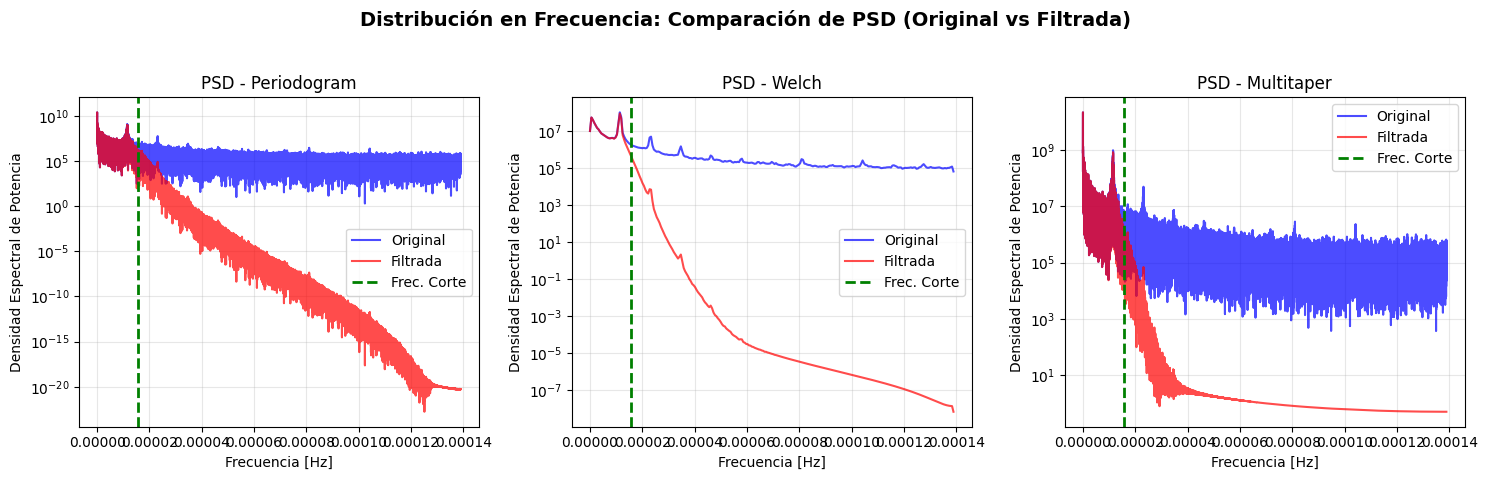

In [5]:
# CÓDIGO OPCIONAL PARA MOSTRAR SOLO LOS GRÁFICOS DE PSD (DISTRIBUCIÓN EN FRECUENCIA)

fig_psd, (ax2_new, ax3_new, ax4_new) = plt.subplots(1, 3, figsize=(15, 5))
fig_psd.suptitle('Distribución en Frecuencia: Comparación de PSD (Original vs Filtrada)',
                 fontsize=14, fontweight='bold')

# --- PSD - Periodogram ---
ax2_new.semilogy(metrics_original['freq_periodogram'], metrics_original['psd_periodogram'],
                 'b-', alpha=0.7, linewidth=1.5, label='Original')
ax2_new.semilogy(metrics_filtered['freq_periodogram'], metrics_filtered['psd_periodogram'],
                 'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax2_new.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label='Frec. Corte')
ax2_new.set_title('PSD - Periodogram')
ax2_new.set_xlabel('Frecuencia [Hz]')
ax2_new.set_ylabel('Densidad Espectral de Potencia')
ax2_new.legend()
ax2_new.grid(True, which="both", ls="-", alpha=0.3)

# --- PSD - Welch ---
ax3_new.semilogy(metrics_original['freq_welch'], metrics_original['psd_welch'],
                 'b-', alpha=0.7, linewidth=1.5, label='Original')
ax3_new.semilogy(metrics_filtered['freq_welch'], metrics_filtered['psd_welch'],
                 'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax3_new.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label='Frec. Corte')
ax3_new.set_title('PSD - Welch')
ax3_new.set_xlabel('Frecuencia [Hz]')
ax3_new.set_ylabel('Densidad Espectral de Potencia')
ax3_new.legend()
ax3_new.grid(True, which="both", ls="-", alpha=0.3)

# --- PSD - Multitaper ---
ax4_new.semilogy(metrics_original['freq_multitaper'], metrics_original['psd_multitaper'],
                 'b-', alpha=0.7, linewidth=1.5, label='Original')
ax4_new.semilogy(metrics_filtered['freq_multitaper'], metrics_filtered['psd_multitaper'],
                 'r-', alpha=0.7, linewidth=1.5, label='Filtrada')
ax4_new.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label='Frec. Corte')
ax4_new.set_title('PSD - Multitaper')
ax4_new.set_xlabel('Frecuencia [Hz]')
ax4_new.set_ylabel('Densidad Espectral de Potencia')
ax4_new.legend()
ax4_new.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generando gráfico de Distribución de Amplitud en la Frecuencia (Espectro de Fourier)...


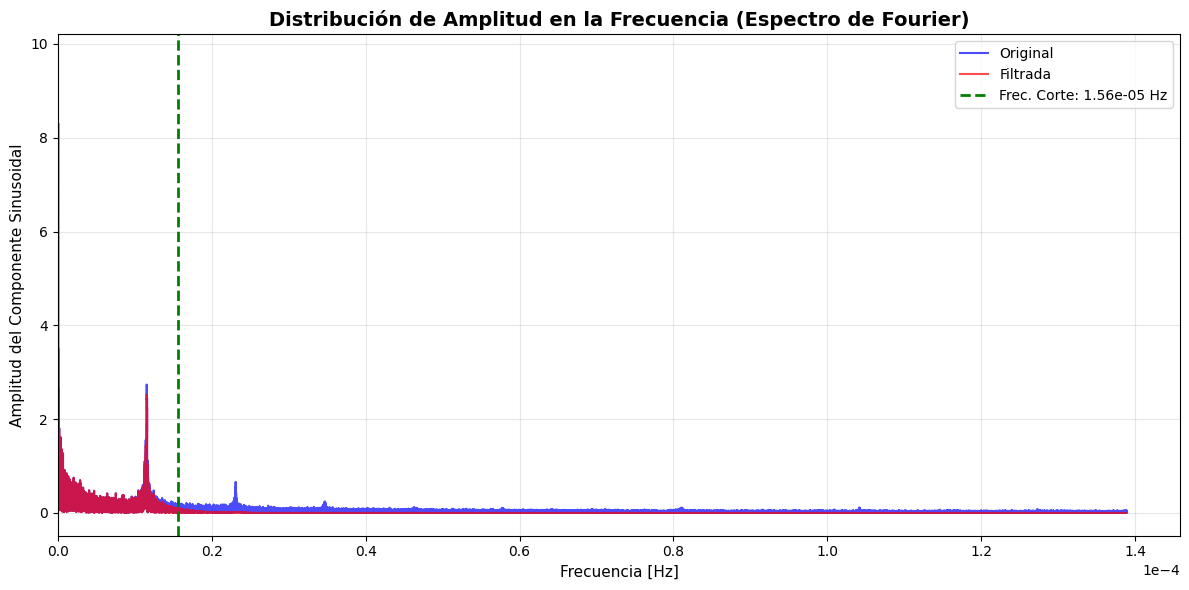


✓ Gráfico de Distribución de Amplitud en la Frecuencia (Espectro de Fourier) generado en 'distribution_frequency_amplitude_fft.png'


In [7]:
# ============================================================================
# DISTRIBUCIÓN DE AMPLITUD EN FRECUENCIA (ESPECTRO DE FOURIER)
# ============================================================================
print("Generando gráfico de Distribución de Amplitud en la Frecuencia (Espectro de Fourier)...")

# --- 1. CÁLCULO DEL ESPECTRO DE FOURIER ---
def calculate_fft_spectrum(data, fs):
    """Calcula la FFT, magnitudes y frecuencias positivas."""
    N = len(data)
    # 1. Calcular la FFT
    Y = np.fft.fft(data)
    # 2. Calcular el vector de frecuencias
    f = np.fft.fftfreq(N, 1/fs)

    # Tomar solo la mitad positiva (espectro de doble lado)
    # Las frecuencias son simétricas, solo se necesita la primera mitad (hasta la frecuencia de Nyquist)

    # Encontrar el índice de Nyquist
    # Nota: np.fft.fftfreq ya ordena la frecuencia en la forma correcta (0, positiva, -negativa)
    # Por simplicidad, tomaremos solo los índices positivos (más allá del 0 y hasta N/2)
    # Asumiremos N es par (más común)
    half_index = N // 2

    # Frecuencias positivas, excluyendo la primera (f=0, componente DC)
    # También se debe tomar solo la mitad positiva de Y
    Y_positive = Y[1:half_index]
    f_positive = f[1:half_index]

    # Calcular la magnitud y normalizar por el número de puntos para obtener la amplitud
    # Se multiplica por 2 porque se descartó la mitad negativa (menos el DC)
    magnitude = 2.0/N * np.abs(Y_positive)

    return f_positive, magnitude

# Calcular para Original y Filtrada
f_orig, mag_orig = calculate_fft_spectrum(humidity_original, fs)
f_filt, mag_filt = calculate_fft_spectrum(humidity_filtered, fs)


# --- 2. GENERACIÓN DEL GRÁFICO DE COMPARACIÓN ---
fig_fft, ax_fft = plt.subplots(figsize=(12, 6))

# Plot Original
ax_fft.plot(f_orig, mag_orig, 'b-', alpha=0.7, linewidth=1.5, label='Original')
# Plot Filtrada
ax_fft.plot(f_filt, mag_filt, 'r-', alpha=0.7, linewidth=1.5, label='Filtrada')

# Línea de la Frecuencia de Corte
ax_fft.axvline(freq_cutoff, color='green', linestyle='--', linewidth=2, label=f'Frec. Corte: {freq_cutoff:.2e} Hz')

ax_fft.set_title('Distribución de Amplitud en la Frecuencia (Espectro de Fourier)', fontsize=14, fontweight='bold')
ax_fft.set_xlabel('Frecuencia [Hz]', fontsize=11)
ax_fft.set_ylabel('Amplitud del Componente Sinusoidal', fontsize=11)
ax_fft.legend()
ax_fft.grid(True, which="both", ls="-", alpha=0.3)
ax_fft.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # Formato científico para el eje X
ax_fft.set_xlim(left=0, right=f_orig[-1] * 1.05) # Asegura que empiece en 0 Hz y tenga un pequeño margen

plt.tight_layout()
plt.savefig('distribution_frequency_amplitude_fft.png', dpi=300)
plt.show()

print("\n✓ Gráfico de Distribución de Amplitud en la Frecuencia (Espectro de Fourier) generado en 'distribution_frequency_amplitude_fft.png'")